# 01 — Exploratory Data Analysis

Load `power.pk`, inspect structure, handle missing values, visualise.

In [1]:
import shutil
import subprocess
import sys
import tempfile
import urllib.request
import zipfile
from pathlib import Path


def clone_repo(repo_url: str, target_dir: Path) -> None:
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', repo_url, str(target_dir)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or result.stdout.strip() or 'git clone failed')


def download_repo_archive(archive_url: str, runtime_dir: Path, repo_dir: Path, extract_dir: Path, archive_path: Path) -> None:
    if archive_path.exists():
        archive_path.unlink()
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    urllib.request.urlretrieve(archive_url, archive_path)
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(runtime_dir)
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    shutil.move(str(extract_dir), str(repo_dir))


def find_or_bootstrap_repo_root() -> Path:
    candidates = [
        Path.cwd().resolve(),
        Path('/tmp/vscode-colab/tesina'),
        Path('/content/tesina'),
        Path('/home/nicola/Desktop/Supsi/tesina'),
    ]
    for base in candidates:
        for candidate in [base, *base.parents]:
            if (candidate / 'src').exists() and (candidate / 'data').exists():
                return candidate

    runtime_dir = Path(tempfile.gettempdir()) / 'vscode-colab'
    repo_dir = runtime_dir / 'tesina'
    archive_path = runtime_dir / 'tesina.zip'
    extract_dir = runtime_dir / 'tesina-master'
    repo_url = 'https://github.com/ncapac/tesina.git'
    archive_url = 'https://codeload.github.com/ncapac/tesina/zip/refs/heads/master'

    runtime_dir.mkdir(parents=True, exist_ok=True)
    if repo_dir.exists() and not (repo_dir / 'src').exists():
        shutil.rmtree(repo_dir)

    if not repo_dir.exists():
        try:
            clone_repo(repo_url, repo_dir)
        except Exception:
            download_repo_archive(archive_url, runtime_dir, repo_dir, extract_dir, archive_path)

    if (repo_dir / 'src').exists() and (repo_dir / 'data').exists():
        return repo_dir

    raise RuntimeError('Could not locate or bootstrap the tesina project root from the current notebook kernel.')


REPO_ROOT = find_or_bootstrap_repo_root()
DATA_DIR = REPO_ROOT / 'data'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.loader import load_raw

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')
print('Project root:', REPO_ROOT)

Project root: /tmp/vscode-colab/tesina


## 1. Load raw data

In [2]:
df = load_raw(DATA_DIR / 'power.pk')
print('Shape (T x N_meters):', df.shape)
print('dtype :', df.dtypes.unique())
print('Index type:', type(df.index))
df.head()

Shape (T x N_meters): (26304, 321)
dtype : [dtype('float32')]
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,0,1,2,3,4,5,6,7,8,9,...,311,312,313,314,315,316,317,318,319,320
2012-01-01 00:00:00,14.0,69.0,234.0,415.0,215.0,1056.0,29.0,840.0,226.0,265.0,...,676.0,372.0,80100.0,4719.0,5002.0,48.0,38.0,1558.0,182.0,2162.0
2012-01-01 01:00:00,18.0,92.0,312.0,556.0,292.0,1363.0,29.0,1102.0,271.0,340.0,...,805.0,452.0,95200.0,4643.0,6617.0,65.0,47.0,2177.0,253.0,2835.0
2012-01-01 02:00:00,21.0,96.0,312.0,560.0,272.0,1240.0,29.0,1025.0,270.0,300.0,...,817.0,430.0,96600.0,4285.0,6571.0,64.0,43.0,2193.0,218.0,2764.0
2012-01-01 03:00:00,20.0,92.0,312.0,443.0,213.0,845.0,24.0,833.0,179.0,211.0,...,801.0,291.0,94500.0,4222.0,6365.0,65.0,39.0,1315.0,195.0,2735.0
2012-01-01 04:00:00,22.0,91.0,312.0,346.0,190.0,647.0,16.0,733.0,186.0,179.0,...,807.0,279.0,91300.0,4116.0,6298.0,75.0,40.0,1378.0,191.0,2721.0


In [3]:
# Basic stats
T, N = df.shape
print(f'Meters: {N}')
print(f'Timesteps: {T}')
if hasattr(df.index, 'freq'):
    print(f'Freq: {df.index.freq}')
print(f'Date range: {df.index[0]}  →  {df.index[-1]}')
print(f'\nGlobal NaN fraction: {df.isna().values.mean():.3%}')
print(f'Meters with >10% NaN: {(df.isna().mean() > 0.1).sum()}')

Meters: 321
Timesteps: 26304
Freq: <Hour>
Date range: 2012-01-01 00:00:00  →  2014-12-31 23:00:00

Global NaN fraction: 0.000%
Meters with >10% NaN: 0


## 2b. Outlier meter identification

Median meter mean: 592.0
Outlier threshold (10× median): 5919.5
Number of outlier meters: 22 / 321

Top-8 meters by mean consumption:
 Meter        Mean         Std   Ratio to median
   313    200529.1    146051.8           338.8x
   155     78701.1     25938.8           133.0x
   236     46173.4     11504.8            78.0x
   167     25457.8      7258.6            43.0x
   186     22692.1      7763.6            38.3x
   315     15678.4      9737.8            26.5x
   290     13026.8      7311.2            22.0x
   179     11524.4      4668.4            19.5x


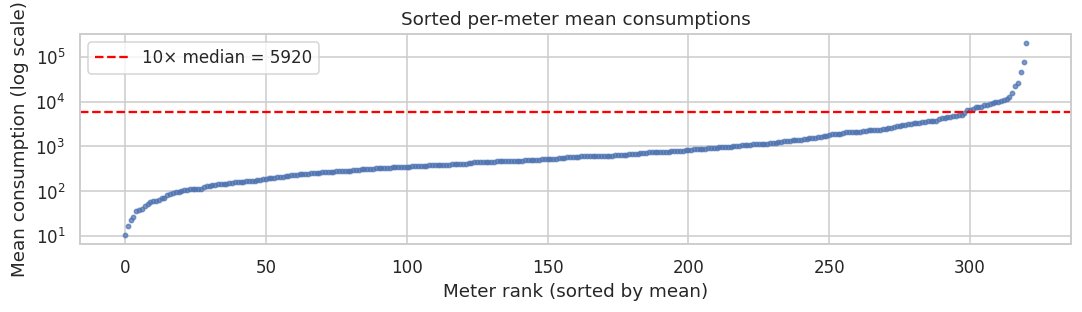

In [4]:
meter_means = np.nanmean(df.values, axis=0)
meter_stds  = np.nanstd(df.values, axis=0)
p50 = np.nanmedian(meter_means)

# Define threshold: >10x the median
outlier_thresh = 10 * p50
outlier_mask   = meter_means > outlier_thresh
print(f'Median meter mean: {p50:.1f}')
print(f'Outlier threshold (10× median): {outlier_thresh:.1f}')
print(f'Number of outlier meters: {outlier_mask.sum()} / {N}')

top_n = 8
top_idx = np.argsort(meter_means)[-top_n:][::-1]
print(f'\nTop-{top_n} meters by mean consumption:')
print(f"{'Meter':>6}  {'Mean':>10}  {'Std':>10}  {'Ratio to median':>16}")
for m in top_idx:
    print(f'{m:>6}  {meter_means[m]:>10.1f}  {meter_stds[m]:>10.1f}  {meter_means[m]/p50:>14.1f}x')

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(range(N), np.sort(meter_means), s=8, alpha=0.7)
ax.axhline(outlier_thresh, color='red', linestyle='--', label=f'10× median = {outlier_thresh:.0f}')
ax.set_yscale('log')
ax.set_xlabel('Meter rank (sorted by mean)')
ax.set_ylabel('Mean consumption (log scale)')
ax.set_title('Sorted per-meter mean consumptions')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Missing value heatmap

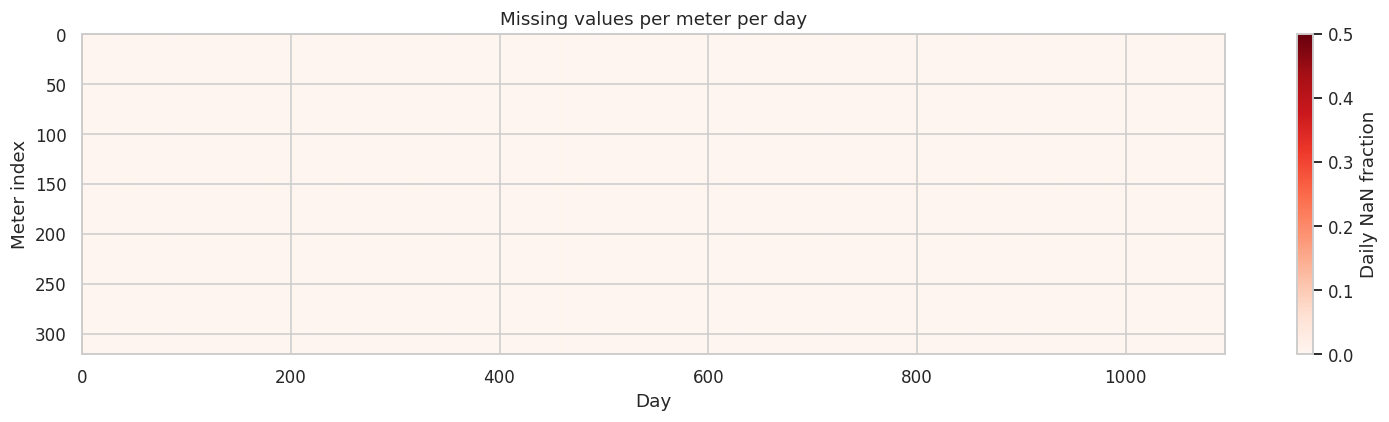

In [5]:
# Resample to daily NaN fraction for a compact heatmap
if isinstance(df.index, pd.DatetimeIndex):
    daily_nan = df.isna().resample('D').mean()  # (days, meters)
    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(daily_nan.T.values, aspect='auto', vmin=0, vmax=0.5, cmap='Reds')
    plt.colorbar(im, ax=ax, label='Daily NaN fraction')
    ax.set_xlabel('Day')
    ax.set_ylabel('Meter index')
    ax.set_title('Missing values per meter per day')
    plt.tight_layout()
    plt.show()
else:
    print('No DatetimeIndex — skip heatmap')

## 3. Sample time series plots

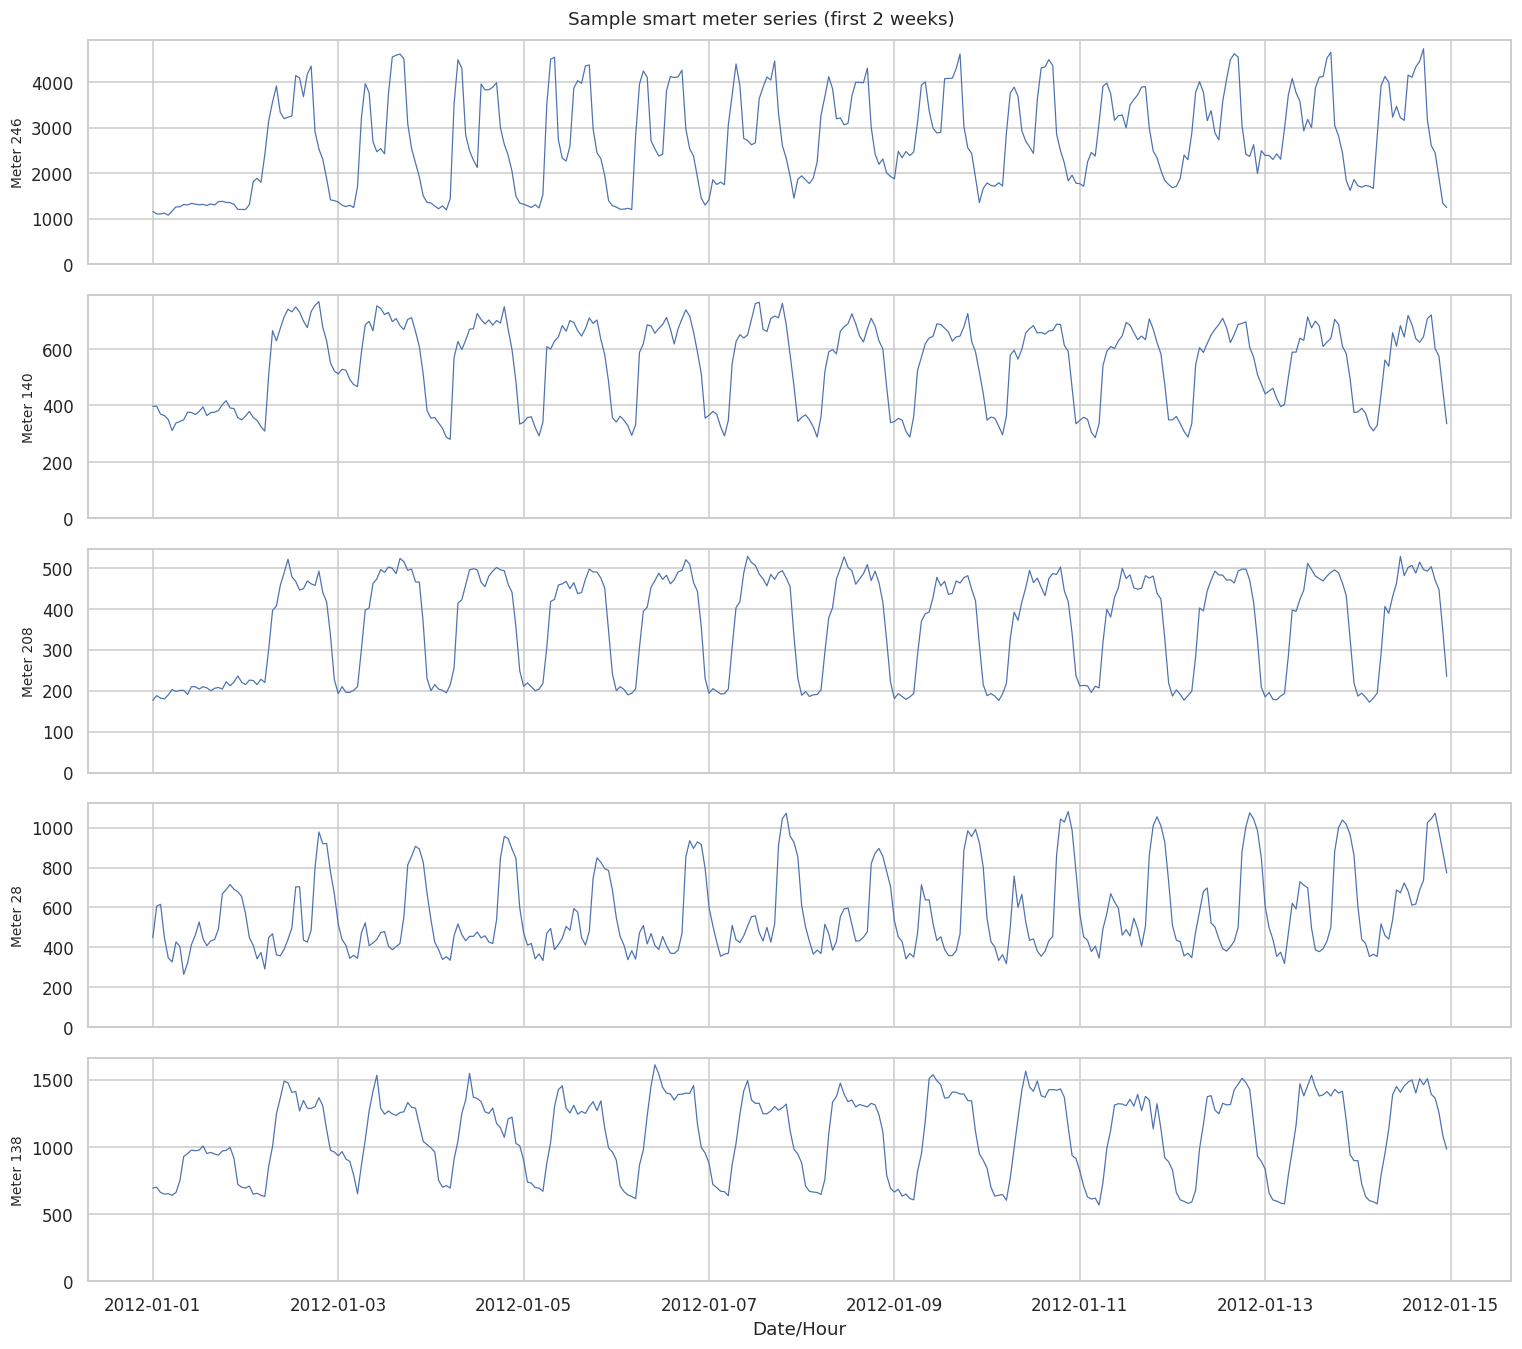

In [6]:
rng = np.random.default_rng(42)
sample_meters = rng.choice(N, size=min(5, N), replace=False)

# Show 2 weeks
show_steps = min(T, 24 * 14)
fig, axes = plt.subplots(len(sample_meters), 1, figsize=(14, 2.5 * len(sample_meters)), sharex=True)
for ax, m in zip(axes, sample_meters):
    ax.plot(df.index[:show_steps], df.iloc[:show_steps, m].values, linewidth=0.8)
    ax.set_ylabel(f'Meter {m}', fontsize=9)
    ax.set_ylim(bottom=0)
axes[-1].set_xlabel('Date/Hour')
fig.suptitle('Sample smart meter series (first 2 weeks)', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Average daily profile (all meters)

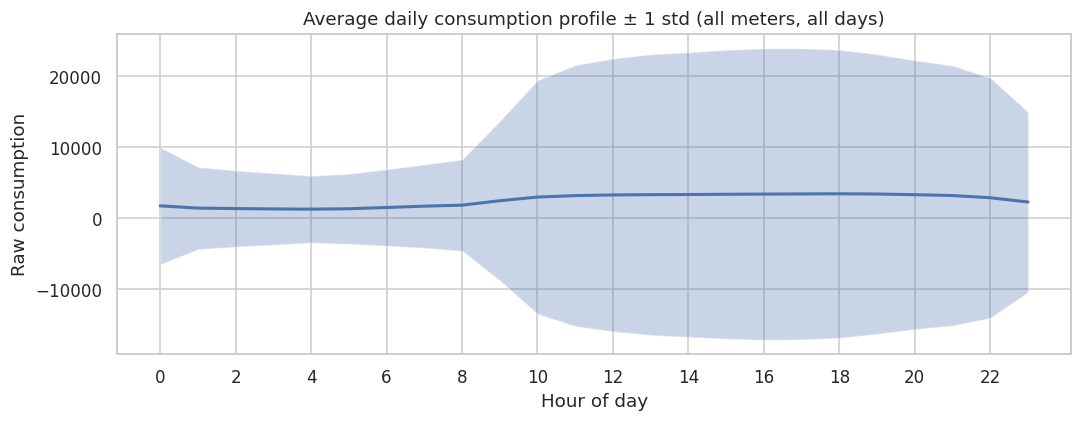

Total complete days: 1096


In [7]:

STEPS_PER_DAY = 24  # hourly resolution — 1 step per hour
n_days = T // STEPS_PER_DAY
values = df.values[:n_days * STEPS_PER_DAY, :]    # (n_days*24, N)
daily = values.reshape(n_days, STEPS_PER_DAY, N)  # (days, 24, N)

mean_profile = np.nanmean(daily, axis=(0, 2))      # (24,)
std_profile  = np.nanstd( daily, axis=(0, 2))

hours = np.arange(STEPS_PER_DAY)                   # 0..23 (each step = 1 h)
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(hours, mean_profile - std_profile,
                        mean_profile + std_profile, alpha=0.3)
ax.plot(hours, mean_profile, linewidth=2)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Raw consumption')
ax.set_title('Average daily consumption profile ± 1 std (all meters, all days)')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

print(f'Total complete days: {n_days}')


## 5. Seasonal heatmap (daily mean per meter)

## 4b. Weekday vs weekend daily profile (normal-scale meters only)

Meters with mean > 10× the median are excluded to compare profiles on a common scale.

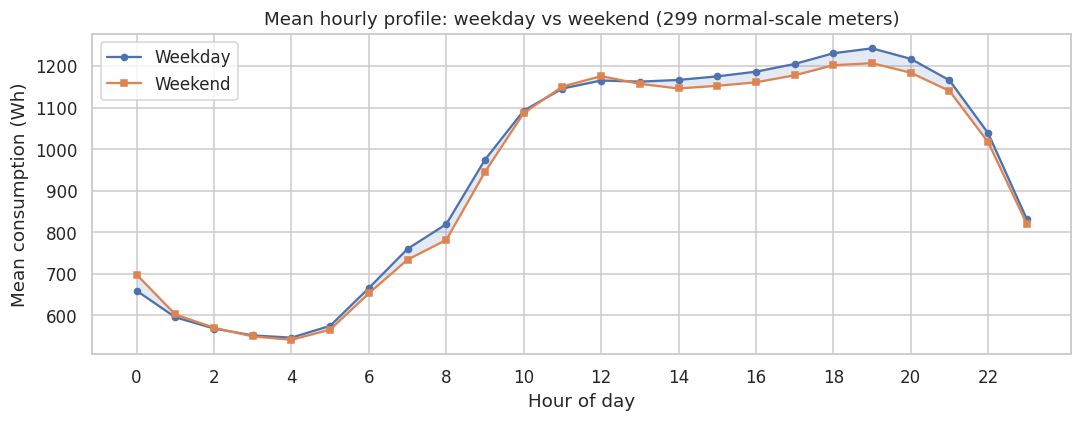

Mean weekday consumption: 947.4
Mean weekend consumption: 933.9
Weekday / weekend ratio: 1.0145

NOTE: The difference is very small (~1.4%).
The day_type CFG conditioning signal is weak in this dataset.


In [8]:
normal_cols = np.where(np.nanmean(df.values, axis=0) <= 10 * np.nanmedian(np.nanmean(df.values, axis=0)))[0]
df_normal = df.iloc[:, normal_cols]

idx = df_normal.index
dow = idx.dayofweek

hourly_wd = np.array([df_normal.loc[(dow < 5) & (idx.hour == h)].values.ravel().mean() for h in range(24)])
hourly_we = np.array([df_normal.loc[(dow >= 5) & (idx.hour == h)].values.ravel().mean() for h in range(24)])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(24), hourly_wd, marker='o', markersize=4, label='Weekday')
ax.plot(range(24), hourly_we, marker='s', markersize=4, label='Weekend')
ax.fill_between(range(24), hourly_wd, hourly_we, alpha=0.15)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean consumption (Wh)')
ax.set_title(f'Mean hourly profile: weekday vs weekend ({len(normal_cols)} normal-scale meters)')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

wd_mean = hourly_wd.mean()
we_mean = hourly_we.mean()
print(f'Mean weekday consumption: {wd_mean:.1f}')
print(f'Mean weekend consumption: {we_mean:.1f}')
print(f'Weekday / weekend ratio: {wd_mean / we_mean:.4f}')
print(f'\nNOTE: The difference is very small (~{abs(wd_mean/we_mean - 1)*100:.1f}%).')
print('The day_type CFG conditioning signal is weak in this dataset.')


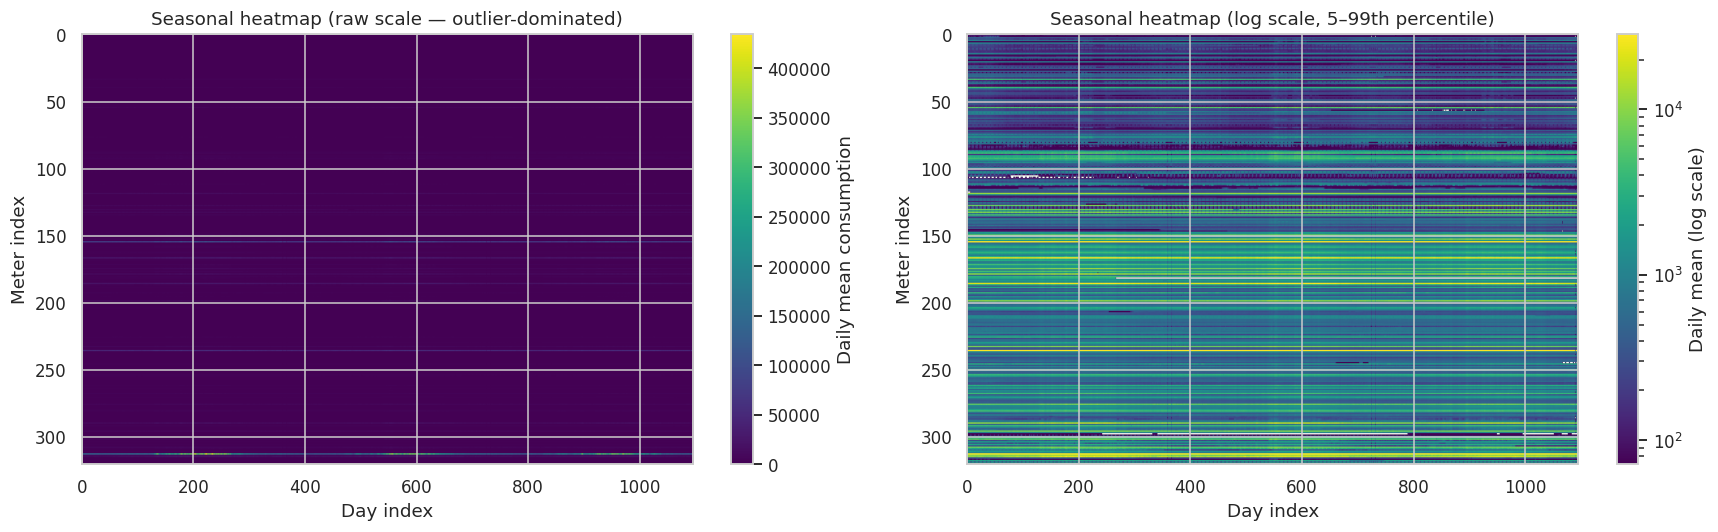

In [9]:
daily_mean = np.nanmean(daily, axis=1)  # (n_days, N)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw scale (dominated by outliers)
im0 = axes[0].imshow(daily_mean.T, aspect='auto', cmap='viridis')
plt.colorbar(im0, ax=axes[0], label='Daily mean consumption')
axes[0].set_xlabel('Day index')
axes[0].set_ylabel('Meter index')
axes[0].set_title('Seasonal heatmap (raw scale — outlier-dominated)')

# Right: log scale to reveal variation across all meters
import matplotlib.colors as mcolors
daily_mean_pos = np.where(daily_mean > 1, daily_mean, np.nan)
vmin = np.nanpercentile(daily_mean_pos, 5)
vmax = np.nanpercentile(daily_mean_pos, 99)
im1 = axes[1].imshow(daily_mean_pos.T, aspect='auto', cmap='viridis',
                     norm=mcolors.LogNorm(vmin=vmin, vmax=vmax))
plt.colorbar(im1, ax=axes[1], label='Daily mean (log scale)')
axes[1].set_xlabel('Day index')
axes[1].set_ylabel('Meter index')
axes[1].set_title('Seasonal heatmap (log scale, 5–99th percentile)')

plt.tight_layout()
plt.show()


## 6. Distribution summary

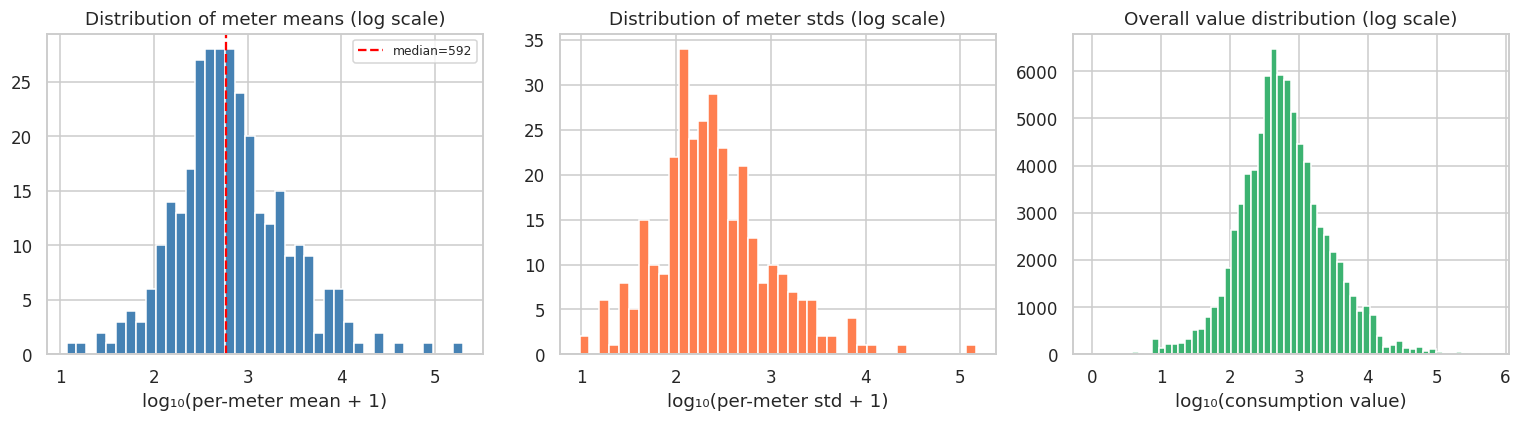

Global min (non-zero): 1.0
Global max: 764000.0
Global mean: 2538.79
Median meter mean: 591.95

Outlier meters (mean > 10× median = 5920): 22 out of 321


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Per-meter mean — log x-axis to reveal structure across orders of magnitude
axes[0].hist(np.log10(meter_means + 1), bins=40, color='steelblue', edgecolor='w')
axes[0].set_xlabel('log₁₀(per-meter mean + 1)')
axes[0].set_title('Distribution of meter means (log scale)')
axes[0].axvline(np.log10(p50 + 1), color='red', linestyle='--', label=f'median={p50:.0f}')
axes[0].legend(fontsize=8)

# Per-meter std — log x-axis
axes[1].hist(np.log10(meter_stds + 1), bins=40, color='coral', edgecolor='w')
axes[1].set_xlabel('log₁₀(per-meter std + 1)')
axes[1].set_title('Distribution of meter stds (log scale)')

# Overall value distribution (subsample, non-zero, log scale)
flat = df.values.ravel()
flat = flat[~np.isnan(flat) & (flat > 0)]
axes[2].hist(np.log10(flat[::100]), bins=60, color='mediumseagreen', edgecolor='w')
axes[2].set_xlabel('log₁₀(consumption value)')
axes[2].set_title('Overall value distribution (log scale)')

plt.tight_layout()
plt.show()

print(f'Global min (non-zero): {flat.min():.1f}')
print(f'Global max: {flat.max():.1f}')
print(f'Global mean: {np.nanmean(df.values):.2f}')
print(f'Median meter mean: {p50:.2f}')
print(f'\nOutlier meters (mean > 10× median = {10*p50:.0f}): {outlier_mask.sum()} out of {N}')


## 7. Observations

**Data structure**
- Shape: (26 304 timesteps × 321 meters), DatetimeIndex at 1-hour resolution, 2012-01-01 → 2014-12-31 (3 complete years, 1 096 days).
- Zero NaN — data is fully clean; the NaN heatmap is uniformly blank.
- Note: project documentation refers to 15-min / 96-step windows. The actual shared dataset is **hourly (24 steps/day)**. All downstream code correctly uses 24 steps/day.

**Outlier meters**
- 22 / 321 meters have mean > 10× the median, dominated by meter 313 (mean ≈ 200 500, ×339 the median). These are almost certainly large industrial/commercial consumers.
- The raw seasonal heatmap is completely dominated by these meters; the log-scale version reveals the variation in normal meters.
- Clustering must be done with scale-awareness (log-transform or robust normalisation) to prevent these meters from distorting cluster centroids.

**Diurnal shape**
- For normal-scale meters (299/321): consumption minimum at ~3–4 h, rising from 6 h, peak at 15–20 h. Consistent with commercial/mixed-use portfolio.
- Weekday vs weekend difference is tiny (**~1.4%**). The hourly profiles are nearly identical across all 24 hours. This suggests the `day_type` conditioning signal is **very weak** in this dataset; the diffusion model should still be able to learn it but discriminative evaluation of CFG guidance quality will be challenging.

**Downstream implications**
- `STEPS_PER_DAY = 24` is correct in `dataset.py`.
- Per-cluster z-score normalisation (implemented in `loader.py`) is the right choice given the large scale heterogeneity.
- Consider using log-transformed values (or at least treating outlier meters as their own cluster) to avoid distorting cluster statistics.
- Week seasonality (Monday–Sunday pattern) is not visible at global level; cluster-level analysis in notebook 02 may reveal it.
